# Exact and IID sampling

Exact sampling constructs draws with the target distribution without an asymptotic discretization limit. We will use inversion, the generalized discrete inverse, Box–Muller, deterministic transforms, and rejection sampling through public package APIs.

The visual checks are paired with identities: an exponential mean, Gaussian moments, the unit-disk radial law $R^2\sim U(0,1)$, and rejection acceptance $\pi/4$.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import sampler_lab
from sampler_lab import spawn_rngs

warnings.filterwarnings("error")
warnings.filterwarnings("ignore", category=PendingDeprecationWarning, module="ipykernel")
QUICK_MODE = os.environ.get("SAMPLER_LAB_NOTEBOOK_MODE") == "quick"
MODE = "quick" if QUICK_MODE else "publication"
plt.rcParams.update({"figure.dpi": 105, "figure.figsize": (7.2, 4.3)})
FIGURE_COUNT = 0
print(f"sampler-lab {sampler_lab.__version__} | execution mode: {MODE}")

from sampler_lab import OperationCounter
from sampler_lab.diagnostics import moment_summary
from sampler_lab.exact import (
    box_muller,
    generalized_inverse_discrete,
    inverse_cdf_sample,
    polar_to_cartesian,
    rejection_sample,
)
from sampler_lab.models import (
    sample_unit_disk_direct,
    sample_unit_disk_rejection,
    unit_disk_radius_squared,
)

sampler-lab 0.12.0 | execution mode: publication


## Inverse-CDF geometry

If $U\sim U(0,1)$, then $F^{-1}(U)$ has CDF $F$. For an exponential distribution with rate one, $F^{-1}(u)=-\log(1-u)$. The left panel shows the deterministic map; the right panel checks the resulting empirical density.

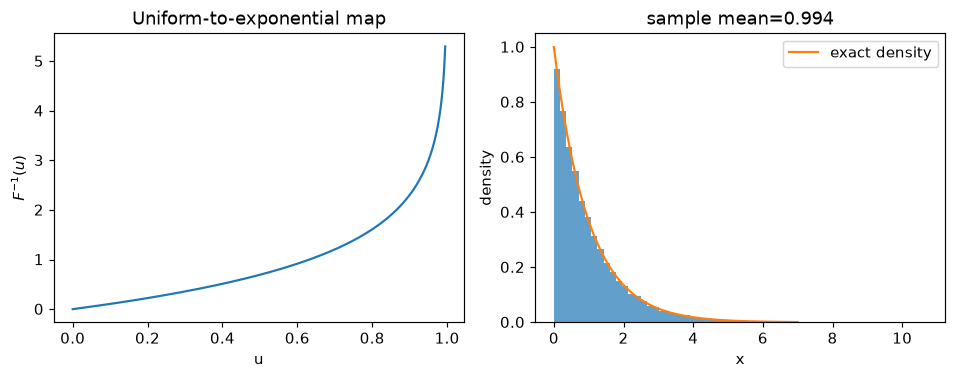

In [2]:
n = 4000 if QUICK_MODE else 20000
inverse_rng = spawn_rngs(202211, 1)[0]
exponential = inverse_cdf_sample(inverse_rng, lambda u: -np.log1p(-u), n)
u_grid = np.linspace(0.0, 0.995, 400)
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.7))
axes[0].plot(u_grid, -np.log1p(-u_grid))
axes[0].set(xlabel="u", ylabel=r"$F^{-1}(u)$", title="Uniform-to-exponential map")
axes[1].hist(exponential, bins=60, density=True, alpha=0.7)
x_grid = np.linspace(0.0, 7.0, 300)
axes[1].plot(x_grid, np.exp(-x_grid), label="exact density")
axes[1].set(xlabel="x", ylabel="density", title=f"sample mean={exponential.mean():.3f}")
axes[1].legend()
fig.tight_layout()
plt.show()
plt.close(fig)
FIGURE_COUNT += 1

For a finite law, the generalized inverse is a step function. `searchsorted(..., side="right")` implements the right-continuous convention and correctly handles zero-probability support points.

In [3]:
discrete_rng = spawn_rngs(202212, 1)[0]
support = np.array([-2.0, 0.0, 3.0, 8.0])
probabilities = np.array([0.1, 0.0, 0.35, 0.55])
discrete = generalized_inverse_discrete(discrete_rng, support, probabilities, n)
frequencies = np.array([(discrete == value).mean() for value in support])
print("target probabilities:", probabilities)
print("empirical frequencies:", np.round(frequencies, 4))

target probabilities: [0.1  0.   0.35 0.55]
empirical frequencies: [0.099  0.     0.3492 0.5518]


## Box–Muller

With independent uniforms $U_1,U_2$,

$$R=\sqrt{-2\log U_1},\qquad \Theta=2\pi U_2,$$

and $(R\cos\Theta,R\sin\Theta)$ has independent standard-normal coordinates. We expect a circular cloud and near-identity covariance.

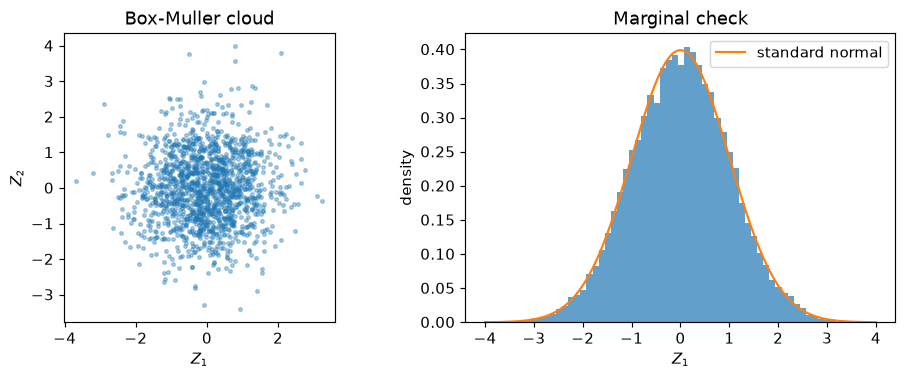

mean: [ 0.0056 -0.0029]
covariance:
 [[0.9989 0.0065]
 [0.0065 0.9964]]
operation counts: {'uniform_draws': 40000, 'normal_draws': 40000, 'log_density_evaluations': 0, 'proposal_density_evaluations': 0, 'gradient_evaluations': 0, 'hessian_evaluations': 0, 'matrix_factorizations': 0, 'conditional_draws': 0, 'spin_updates': 0, 'particle_propagations': 0, 'policy_evaluations': 0, 'training_objective_evaluations': 0, 'extra': {}}


In [4]:
normal_rng = spawn_rngs(202213, 1)[0]
counter = OperationCounter()
normals = box_muller(normal_rng, 2 * n, counter=counter).reshape(n, 2)
summary = moment_summary(normals)
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.7))
axes[0].scatter(normals[:1500, 0], normals[:1500, 1], s=6, alpha=0.35)
axes[0].set(xlabel="$Z_1$", ylabel="$Z_2$", title="Box-Muller cloud", aspect="equal")
axes[1].hist(normals[:, 0], bins=60, density=True, alpha=0.7)
x_grid = np.linspace(-4, 4, 300)
axes[1].plot(x_grid, np.exp(-0.5 * x_grid**2) / np.sqrt(2 * np.pi), label="standard normal")
axes[1].set(xlabel="$Z_1$", ylabel="density", title="Marginal check")
axes[1].legend()
fig.tight_layout()
plt.show()
plt.close(fig)
FIGURE_COUNT += 1
print("mean:", np.round(summary.mean, 4))
print("covariance:\n", np.round(summary.covariance, 4))
print("operation counts:", counter.snapshot())

## Uniform area measure on the unit disk

Uniform radius is **not** uniform area. Since $P(R\le r)=r^2$, exact direct sampling uses $R=\sqrt U$. The repository also includes square rejection; with a tight square envelope its theoretical acceptance is $\pi/4$.

This repeats the console demo's target and seed (`2022`) so its deterministic summaries agree with `sampler-lab-disk-benchmark` apart from timing noise.

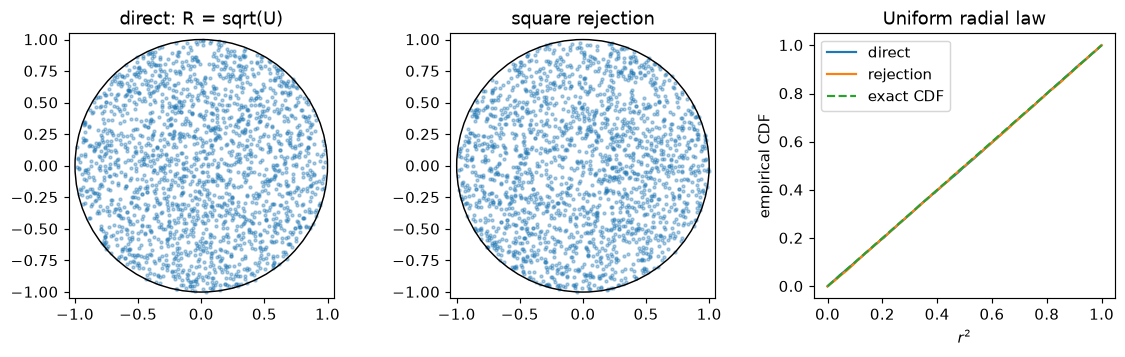

direct E[R^2]=0.5015; rejection E[R^2]=0.5019
acceptance=0.7884; pi/4=0.7854
direct counts: {'uniform_draws': 60000, 'normal_draws': 0, 'log_density_evaluations': 0, 'proposal_density_evaluations': 0, 'gradient_evaluations': 0, 'hessian_evaluations': 0, 'matrix_factorizations': 0, 'conditional_draws': 0, 'spin_updates': 0, 'particle_propagations': 0, 'policy_evaluations': 0, 'training_objective_evaluations': 0, 'extra': {}}
rejection counts: {'uniform_draws': 114159, 'normal_draws': 0, 'log_density_evaluations': 38053, 'proposal_density_evaluations': 38053, 'gradient_evaluations': 0, 'hessian_evaluations': 0, 'matrix_factorizations': 0, 'conditional_draws': 0, 'spin_updates': 0, 'particle_propagations': 0, 'policy_evaluations': 0, 'training_objective_evaluations': 0, 'extra': {'extra_proposals': 38053}}


In [5]:
disk_n = 5000 if QUICK_MODE else 30000
direct_rng, rejection_rng, bad_rng = spawn_rngs(2022, 3)
direct_counter = OperationCounter()
rejection_counter = OperationCounter()
direct = sample_unit_disk_direct(direct_rng, disk_n, counter=direct_counter)
rejection = sample_unit_disk_rejection(rejection_rng, disk_n, counter=rejection_counter)
bad_radius = bad_rng.random(disk_n)
bad_angle = 2 * np.pi * bad_rng.random(disk_n)
bad = polar_to_cartesian(bad_radius, bad_angle)
direct_r2 = unit_disk_radius_squared(direct)
rejection_r2 = unit_disk_radius_squared(rejection.samples)
bad_r2 = unit_disk_radius_squared(bad)
fig, axes = plt.subplots(1, 3, figsize=(11.0, 3.5))
for ax, points, title in zip(
    axes[:2], [direct, rejection.samples], ["direct: R = sqrt(U)", "square rejection"], strict=True
):
    ax.scatter(points[:2000, 0], points[:2000, 1], s=4, alpha=0.35)
    circle = plt.Circle((0, 0), 1, fill=False)
    ax.add_patch(circle)
    ax.set(xlim=(-1.05, 1.05), ylim=(-1.05, 1.05), aspect="equal", title=title)
axes[2].plot(np.sort(direct_r2), np.linspace(0, 1, disk_n, endpoint=False), label="direct")
axes[2].plot(np.sort(rejection_r2), np.linspace(0, 1, disk_n, endpoint=False), label="rejection")
axes[2].plot([0, 1], [0, 1], "--", label="exact CDF")
axes[2].set(xlabel="$r^2$", ylabel="empirical CDF", title="Uniform radial law")
axes[2].legend()
fig.tight_layout()
plt.show()
plt.close(fig)
FIGURE_COUNT += 1
print(f"direct E[R^2]={direct_r2.mean():.4f}; rejection E[R^2]={rejection_r2.mean():.4f}")
print(f"acceptance={rejection.acceptance_rate:.4f}; pi/4={np.pi / 4:.4f}")
print("direct counts:", direct_counter.snapshot())
print("rejection counts:", rejection_counter.snapshot())

## Controlled failure: sampling radius uniformly

If $R\sim U(0,1)$, then $E[R^2]=1/3$ rather than $1/2$, and the center is overpopulated. This failure can look superficially plausible in a point cloud; the radial CDF exposes it immediately.

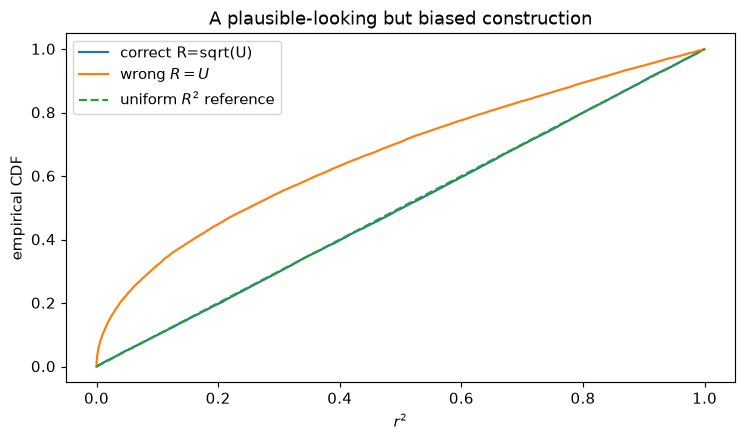

wrong construction E[R^2]=0.3327; expected 1/3


In [6]:
fig, ax = plt.subplots()
ax.plot(np.sort(direct_r2), np.linspace(0, 1, disk_n, endpoint=False), label="correct R=sqrt(U)")
ax.plot(np.sort(bad_r2), np.linspace(0, 1, disk_n, endpoint=False), label="wrong $R=U$")
ax.plot([0, 1], [0, 1], "--", label="uniform $R^2$ reference")
ax.set(xlabel="$r^2$", ylabel="empirical CDF", title="A plausible-looking but biased construction")
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)
FIGURE_COUNT += 1
print(f"wrong construction E[R^2]={bad_r2.mean():.4f}; expected 1/3")

## Generic rejection interface and envelope validation

The target may be unnormalized, but the declared envelope must dominate it everywhere the proposal can reach. The implementation checks evaluated points and raises rather than quietly biasing the result.

In [7]:
def proposal(generator, size):
    return generator.uniform(-1.0, 1.0, size=size)


def log_target(point):
    x = float(point)
    return np.log1p(x) if -1.0 < x <= 1.0 else float("-inf")


def log_proposal(point):
    del point
    return -np.log(2.0)


triangular_rng = spawn_rngs(202214, 1)[0]
triangular = rejection_sample(
    triangular_rng, 2500 if QUICK_MODE else 12000, proposal, log_target, log_proposal, np.log(4.0)
)
try:
    rejection_sample(spawn_rngs(202215, 1)[0], 50, proposal, log_target, log_proposal, np.log(2.0))
except ValueError as error:
    envelope_error = str(error)
else:
    envelope_error = "missing validation"
print(
    f"triangular mean={triangular.samples.mean():.3f} (exact 1/3); "
    f"acceptance={triangular.acceptance_rate:.3f}"
)
print("invalid envelope check:", envelope_error)

triangular mean=0.339 (exact 1/3); acceptance=0.502
invalid envelope check: proposal envelope is invalid: observed log acceptance ratio 0.606047 > 0


## When to use exact methods

Use inversion when the generalized inverse is tractable, transformations when a simple base law maps cleanly to the target, and rejection when a proposal admits a verified global envelope. Rejection becomes poor when the envelope is loose or dimension makes the target occupy a tiny proposal volume.

Further experiments: derive a direct sampler for a ball in dimension $d$; compare empirical proposal cost to the exact volume ratio; or construct a discrete law with repeated support values.

In [8]:
assert abs(exponential.mean() - 1.0) < (0.06 if QUICK_MODE else 0.025)
assert np.max(np.abs(frequencies - probabilities)) < (0.035 if QUICK_MODE else 0.015)
assert np.max(np.abs(summary.mean)) < 0.08
assert np.max(np.abs(summary.covariance - np.eye(2))) < 0.10
assert abs(direct_r2.mean() - 0.5) < 0.03
assert abs(rejection_r2.mean() - 0.5) < 0.03
assert abs(rejection.acceptance_rate - np.pi / 4) < 0.04
assert abs(bad_r2.mean() - 1 / 3) < 0.03
assert "invalid" in envelope_error
EXPECTED_FIGURES = 4
assert FIGURE_COUNT == EXPECTED_FIGURES
print(f"Notebook checks passed; expected figures: {EXPECTED_FIGURES}")

Notebook checks passed; expected figures: 4
